# Hybrid Regime Forecaster: HMM posteriors → XGBoost

**Question:** In notebook 10 we compared the **GaussianHMM** (unsupervised) and **XGBoost** (supervised) head-to-head. Here we stop treating them as rivals and **combine** them: we feed the HMM's per-bar *regime posterior* into XGBoost as extra features, and ask it to **forecast the next bar's regime**.

The intuition: the two models are good at different things.

| | strength | weakness |
|---|---|---|
| **GaussianHMM** | *persistence* — its transition matrix knows regimes are sticky, so its view is smooth and coherent over time | only sees a Gaussian summary of the features |
| **XGBoost** | *microstructure* — non-linear interactions between order-flow features | classifies each bar **independently**, so its forecast flickers from bar to bar with no memory |

The **hybrid** gives XGBoost the HMM's posterior `P(regime | data so far)` as four extra inputs — handing it the HMM's memory on a plate, while keeping XGBoost's raw microstructure features. We then check, honestly, whether that combination beats either model alone.

> All data here is **synthetic** order flow with known ground-truth regimes (same generator as notebooks 09–10), so we can score each model against the truth. The synthetic mimics IDX-style intraday microstructure: session U-shapes, fat tails, sticky regimes, aggressor flow (*hajar kiri/hajar kanan*).

## TL;DR

We forecast the **next bar's regime** (calm / buy_pressure / sell_pressure / volatile) on a held-out 30% test slice, and score three models:

| model | features | accuracy | macro-F1 |
|---|---|---|---|
| **HMM-only** | propagate the HMM posterior one step through its own transition matrix | 0.77 | 0.72 |
| **XGBoost baseline** | 6 microstructure features only | 0.68 | 0.60 |
| **Hybrid** | 6 microstructure features **+ 4 HMM posteriors** | **0.79** | **0.72** |

**Three takeaways:**
1. **Persistence dominates forecasting.** The microstructure-only XGBoost is the **weakest** forecaster — *worse* than the simple HMM — because it has no memory and flickers. This is the mirror image of notebook 10, where for *detection* XGBoost edged ahead.
2. **The hybrid is the best of both.** Adding the HMM posteriors lifts XGBoost's macro-F1 from ~0.60 to ~0.72 (**+0.12**) and gives it the **highest accuracy of all three**.
3. **The posteriors do the heavy lifting.** The four `prob_*` columns are the top features by importance — exactly the temporal coherence the raw features lacked.

The closing **early-warning experiment (H1)** then shows the hybrid can go from *tying* the HMM to *beating* it once the data contains a microstructure precursor to regime change — the signature to look for in the real feed.

## How this relates to notebook 10 (detection vs. forecasting)

If you remember notebook 10, **XGBoost beat the HMM** there (≈0.75 vs 0.70 ARI, ≈0.90 accuracy). In this notebook the HMM and the hybrid sit *ahead* of plain XGBoost. **These do not contradict each other — they are two different tasks:**

| | task | label | who wins |
|---|---|---|---|
| **Notebook 10** | **Detection** — what regime are we in *now*? | current regime | XGBoost |
| **Notebook 11 (this one)** | **Forecasting** — what regime will the *next* bar be? | next-bar regime | HMM / Hybrid |

Detection rewards reading the present from features (XGBoost's strength). Forecasting a *sticky* series rewards **memory** of where we are and how regimes flow (the HMM's transition matrix). Plain XGBoost has no memory, so it classifies each bar independently and *flickers* — which is why, for forecasting, it falls behind the HMM until we hand it the HMM's posteriors (the hybrid). Same models, different task, opposite result — for a reason.

## How the hybrid is wired

```
synthetic order flow
        │
        ▼
   10-min bars ──► 6 microstructure features  ─────────────────┐
        │                                                       │
        │   (de-seasonalize, scale, GaussianHMM, online filter) │  raw features
        ▼                                                       │  (point-in-time)
   HMM filtered posterior  P(regime_t | data up to t)           │
        │  prob_0 … prob_3   ← causal: uses only past + present  │
        └───────────────────────────────────────────────────────┤
                                                                 ▼
                                          XGBoost  ──►  forecast regime_(t+1)
```

Two things that make this honest and deployable:

- **The posteriors are *causal*.** They come from the online **forward filter** (`src/online.py`), which uses only past-and-present bars — never the future. So `prob_*` at bar *t* is a legitimate input for predicting bar *t+1*. (Contrast with `model.predict_proba`, which smooths using the whole sequence and would leak the future.)
- **It works on the real feed.** On real data there are no ground-truth regime labels, but the HMM still runs unsupervised and its filtered posterior is still causal — so the same hybrid is buildable day one (see the closing caveats for the "HMM-as-teacher" target).

In [1]:
import sys, warnings
from pathlib import Path

# Make the src/ package importable whether we run from repo root or notebooks/.
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

from src import config
from src.ingest.synthetic_adapter import SyntheticAdapter
from src.bars import build_bars
from src.features import compute_features
from src.backtest import train_and_backtest                 # HMM pipeline (gives causal posteriors)
from src.xgb.targets import make_regime_forecast_target, REGIME_NAMES
from src.xgb.model_xgb import train_classifier, feature_importance   # reuse the gen-2 XGB wrapper

warnings.filterwarnings("ignore")           # quiet hmmlearn/sklearn convergence chatter
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

# Same regime colors as the HMM/forecaster figures, so everything is visually comparable.
REGIME_COLORS = {0: "#aec7e8", 1: "#2ca02c", 2: "#d62728", 3: "#ff7f0e"}

# --- A one-line legend for the shorthand used below ----------------------------
# accuracy   : fraction of bars whose next-regime forecast was exactly right.
# macro-F1   : F1 averaged equally over the 4 regimes (so rare 'volatile' counts
#              as much as common 'calm'); random guessing ~ 0.25.
# posterior  : P(regime_t | data up to t)  - the HMM's belief over regimes *now*.
# causal/online: uses only past + present bars, never the future (no leakage).
REGIME_NAMES

{0: 'calm', 1: 'buy_pressure', 2: 'sell_pressure', 3: 'volatile'}

## Step 1 — Build the data and get the HMM's causal posteriors

`train_and_backtest` runs the whole HMM pipeline exactly as the live detector would: de-seasonalize → scale → fit a GaussianHMM (number of states chosen by BIC) on the **train** window, then run the **online forward filter** bar-by-bar over the full history. The returned frame already carries the per-bar filtered posteriors `prob_0 … prob_{n-1}` — the very thing we want to feed XGBoost.

In [2]:
adapter = SyntheticAdapter(symbol="DEMO", n_days=40, seed=7)
features = compute_features(build_bars(adapter.stream()))   # 6 point-in-time features per bar
truth = adapter.truth                                       # bar_start.isoformat() -> true regime id

# Fit HMM on the train window, then online-filter every bar. `split` = the 70/30 cut.
hmm_frame, hmm_artifact, split = train_and_backtest(features)
n_states = hmm_artifact["meta"]["n_states"]
prob_cols = [f"prob_{s}" for s in range(n_states)]

print(f"\n{len(features)} bars | HMM states chosen by BIC: {n_states}")
print(f"posterior columns (causal, online-filtered): {prob_cols}")
hmm_frame[["filt_state", "filt_label"] + prob_cols].head()

n=2 | AIC: 10050.91 | BIC: 10318.36 | Converged: True
n=3 | AIC: 9081.31 | BIC: 9498.91 | Converged: True


n=4 | AIC: 8886.04 | BIC: 9463.16 | Converged: True


n=5 | AIC: 8810.17 | BIC: 9556.22 | Converged: True


n=6 | AIC: 8843.27 | BIC: 9767.61 | Converged: True

Best number of states by BIC: 4
HMM converged: True



1152 bars | HMM states chosen by BIC: 4
posterior columns (causal, online-filtered): ['prob_0', 'prob_1', 'prob_2', 'prob_3']


,filt_state,filt_label,prob_0,prob_1,prob_2,prob_3
bar_start,,,,,,
2026-01-05 09:10:00+07:00,0,Quiet / Ranging,1.000000e+00,6.765515e-79,8.876399e-135,4.077434e-60
2026-01-05 09:20:00+07:00,0,Quiet / Ranging,9.999068e-01,1.491954e-05,8.486838e-09,7.829739e-05
2026-01-05 09:30:00+07:00,0,Quiet / Ranging,9.999632e-01,3.192511e-07,4.969791e-09,3.651391e-05
2026-01-05 09:40:00+07:00,2,Volatile / Choppy,2.307829e-61,2.458970e-20,1.000000e+00,2.020990e-25
2026-01-05 09:50:00+07:00,2,Volatile / Choppy,2.195554e-40,6.239802e-13,1.000000e+00,3.740187e-19


### Interpreting the HMM's states (so we can score it fairly)

The HMM is **unsupervised**, so its state numbers are arbitrary — "state 2" carries no inherent meaning and could be relabelled on a re-fit. To compare the HMM against the true regimes, we learn a **map** from each HMM state to the regime it most often coincides with — using the **training bars only** (so it's an honest, point-in-time mapping, not fitted to the test set).

This map is used in two places below: to *color* the posterior plot, and to translate the HMM-only forecast into regime ids so it can be scored.

In [3]:
true_now = pd.Series([truth.get(ts.isoformat()) for ts in features.index],
                     index=features.index, name="true_regime")
hmm_state = hmm_frame["filt_state"]
is_train_full = np.arange(len(features)) < split

# For each HMM state, the most common TRUE regime among training bars in that state.
state_to_regime = {}
for s in range(n_states):
    in_state_train = (hmm_state.values == s) & is_train_full & true_now.notna().values
    state_to_regime[s] = (int(pd.Series(true_now.values[in_state_train]).mode().iloc[0])
                          if in_state_train.any() else 0)

print("HMM state -> regime (learned on train only):")
for s in range(n_states):
    print(f"   state {s}  ->  {state_to_regime[s]} ({REGIME_NAMES[state_to_regime[s]]})")

HMM state -> regime (learned on train only):
   state 0  ->  0 (calm)
   state 1  ->  1 (buy_pressure)
   state 2  ->  3 (volatile)
   state 3  ->  2 (sell_pressure)


**The posteriors are sticky, not flickery.** Below is the HMM's filtered posterior over a slice of the test period. Notice how one regime's probability stays high for several bars at a time before handing off — that persistence is the "memory" we are about to lend to XGBoost. Each band is colored by the regime its state maps to.

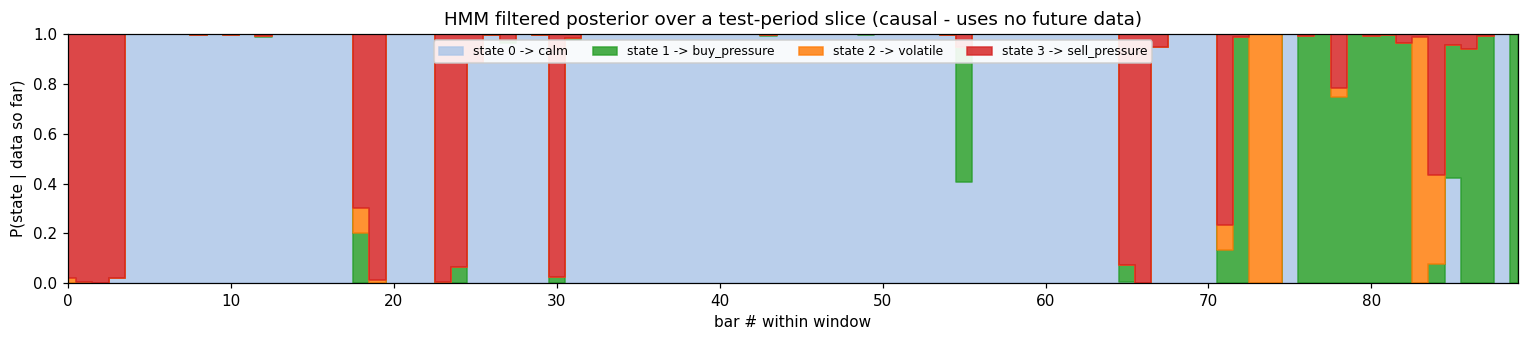

In [4]:
# A contiguous 90-bar window inside the test region, for legibility.
window = slice(split, split + 90)
posteriors = hmm_frame[prob_cols].iloc[window].values        # (bars, n_states)
x = np.arange(posteriors.shape[0])

fig, ax = plt.subplots(figsize=(14, 3.2))
bottom = np.zeros(len(x))
for s in range(n_states):
    regime = state_to_regime[s]
    ax.fill_between(x, bottom, bottom + posteriors[:, s], step="mid",
                    color=REGIME_COLORS[regime], alpha=0.85,
                    label=f"state {s} -> {REGIME_NAMES[regime]}")
    bottom += posteriors[:, s]
ax.set_xlim(0, len(x) - 1); ax.set_ylim(0, 1)
ax.set_title("HMM filtered posterior over a test-period slice (causal - uses no future data)")
ax.set_xlabel("bar # within window"); ax.set_ylabel("P(state | data so far)")
ax.legend(loc="upper center", ncol=n_states, fontsize=8, framealpha=0.9)
plt.tight_layout(); plt.show()

## Step 2 — The forecasting target

We predict the **regime of the *next* bar** (`horizon=1`), within the same session — so the model learns to *anticipate* the regime, not just describe the current one. The discipline that keeps this honest:

- **Features are point-in-time; only the *target* looks ahead.** At bar *t* the inputs use data up to *t*; the label is what regime *t+1* turns out to be. No feature ever sees the future.
- **Forward windows never bridge a session boundary.** The last bar of each session has no "next bar" in-session, so its target is undefined and dropped.
- **No de-seasonalization here** (unlike notebook 10's *detection* setup). For *forecasting* next-bar volatility/regime, the time-of-day level is genuinely **predictive** — late-session bars are systematically calmer/busier — so we keep the raw features. (The HMM posteriors, by contrast, were already built on de-seasonalized inputs internally; the hybrid gets both views.)

In [5]:
# Next-bar regime label; valid_mask drops session-final bars that have no 'next'.
regime_target, valid_mask = make_regime_forecast_target(features, truth, horizon=1)
regime_target = regime_target[valid_mask].astype(int)

# Same time-ordered 70/30 split as the HMM, restricted to bars with a valid target.
is_train = is_train_full[valid_mask.values]

base_cols = config.FEATURE_COLS                      # 6 microstructure features
hybrid_cols = config.FEATURE_COLS + prob_cols        # + 4 causal HMM posteriors

# Both matrices come from the SAME frame, so they are aligned row-for-row.
base_features = hmm_frame.loc[valid_mask, base_cols]
hybrid_features = hmm_frame.loc[valid_mask, hybrid_cols]
target_test = regime_target[~is_train]

print(f"usable bars: {len(regime_target)}  (train {int(is_train.sum())}, test {int((~is_train).sum())})")
print(f"baseline feature set : {base_cols}")
print(f"hybrid feature set   : +{prob_cols}\n")
print("next-bar regime class balance (all usable bars):")
print(regime_target.value_counts().rename(REGIME_NAMES).sort_index())

usable bars: 1072  (train 751, test 321)
baseline feature set : ['ret', 'signed_vol_imb', 'ofi', 'rel_spread', 'realized_vol', 'trade_intensity']
hybrid feature set   : +['prob_0', 'prob_1', 'prob_2', 'prob_3']

next-bar regime class balance (all usable bars):
regime
buy_pressure     267
calm             461
sell_pressure    232
volatile         112
Name: count, dtype: int64


## Step 3 — Three forecasters on the same test set

- **Model A — HMM-only (a *naive persistence baseline*, not a real forecaster).** No XGBoost. Take the HMM's posterior at bar *t* — its belief about the regime we're in **now** (detection) — and push it one step through the HMM's **own transition matrix** to get `P(regime_{t+1})`, then take the most likely regime. This is **not** the HMM anticipating change; it's *"detect the current regime, then assume it persists."* Because the transition matrix is sticky, it mostly predicts *"same as now."* It's a strong **baseline** precisely because regimes are persistent — but it is blind to regime *turns*, which is the gap the hybrid aims to fill. (Same projection notebook 06 did, and called *"a nowcast projected forward, not a true forecast."*)
- **Model B — XGBoost baseline.** The gen-2 forecaster: 6 microstructure features → next-bar regime.
- **Model C — Hybrid.** Identical XGBoost (same hyper-parameters), but the feature set also includes the 4 HMM posteriors. The *only* difference from Model B is those 4 columns, so any gap is attributable to them.

In [6]:
# --- Model A: HMM-only forecast (propagate posterior through the transition matrix) ---
transmat = hmm_artifact["model"].transmat_                       # P(state_{t+1} | state_t)
posteriors_test = hmm_frame.loc[valid_mask, prob_cols].values[~is_train]
next_state = (posteriors_test @ transmat).argmax(axis=1)         # most likely next STATE
hmm_pred = np.array([state_to_regime[s] for s in next_state])    # -> regime id via train map
print("Model A (HMM-only) ready.")

Model A (HMM-only) ready.


In [7]:
# --- Models B & C: baseline vs hybrid XGBoost (same hyper-parameters; only features differ) ---
baseline_clf = train_classifier(base_features[is_train],   regime_target[is_train])
hybrid_clf   = train_classifier(hybrid_features[is_train], regime_target[is_train])

baseline_pred = baseline_clf.predict(base_features[~is_train])
hybrid_pred   = hybrid_clf.predict(hybrid_features[~is_train])
print("Models B (baseline) and C (hybrid) trained.")

Models B (baseline) and C (hybrid) trained.


## Results

In [8]:
def score(pred):
    return accuracy_score(target_test, pred), f1_score(target_test, pred, average="macro")

rows = []
for name, pred in [("HMM-only (transition matrix)", hmm_pred),
                   ("XGBoost baseline (6 micro feats)", baseline_pred),
                   ("Hybrid (6 micro + 4 HMM posteriors)", hybrid_pred)]:
    acc, f1 = score(pred)
    rows.append({"model": name, "accuracy": round(acc, 3), "macro-F1": round(f1, 3)})

results = pd.DataFrame(rows).set_index("model")
lift = results.loc["Hybrid (6 micro + 4 HMM posteriors)", "macro-F1"] - \
       results.loc["XGBoost baseline (6 micro feats)", "macro-F1"]
print("next-bar regime forecast - out-of-sample (test = last 30%)\n")
print(results.to_string())
print(f"\nhybrid lift over the microstructure-only baseline: {lift:+.3f} macro-F1")

next-bar regime forecast - out-of-sample (test = last 30%)

                                     accuracy  macro-F1
model                                                  
HMM-only (transition matrix)            0.766     0.718
XGBoost baseline (6 micro feats)        0.676     0.596
Hybrid (6 micro + 4 HMM posteriors)     0.794     0.720

hybrid lift over the microstructure-only baseline: +0.124 macro-F1


In [9]:
# Per-class detail for the core A/B comparison (baseline vs hybrid).
names = [REGIME_NAMES[c] for c in sorted(REGIME_NAMES)]
for title, pred in [("XGBoost baseline", baseline_pred), ("Hybrid", hybrid_pred)]:
    print(f"================ {title} ================")
    print(classification_report(target_test, pred, labels=sorted(REGIME_NAMES),
                                target_names=names, digits=3, zero_division=0))

================ XGBoost baseline ================
               precision    recall  f1-score   support

         calm      0.697     0.759     0.726       112
 buy_pressure      0.806     0.686     0.741       121
sell_pressure      0.553     0.667     0.604        63
     volatile      0.350     0.280     0.311        25

     accuracy                          0.676       321
    macro avg      0.601     0.598     0.596       321
 weighted avg      0.683     0.676     0.676       321

================ Hybrid ================
               precision    recall  f1-score   support

         calm      0.819     0.848     0.833       112
 buy_pressure      0.892     0.818     0.853       121
sell_pressure      0.680     0.810     0.739        63
     volatile      0.526     0.400     0.455        25

     accuracy                          0.794       321
    macro avg      0.729     0.719     0.720       321
 weighted avg      0.796     0.794     0.793       321



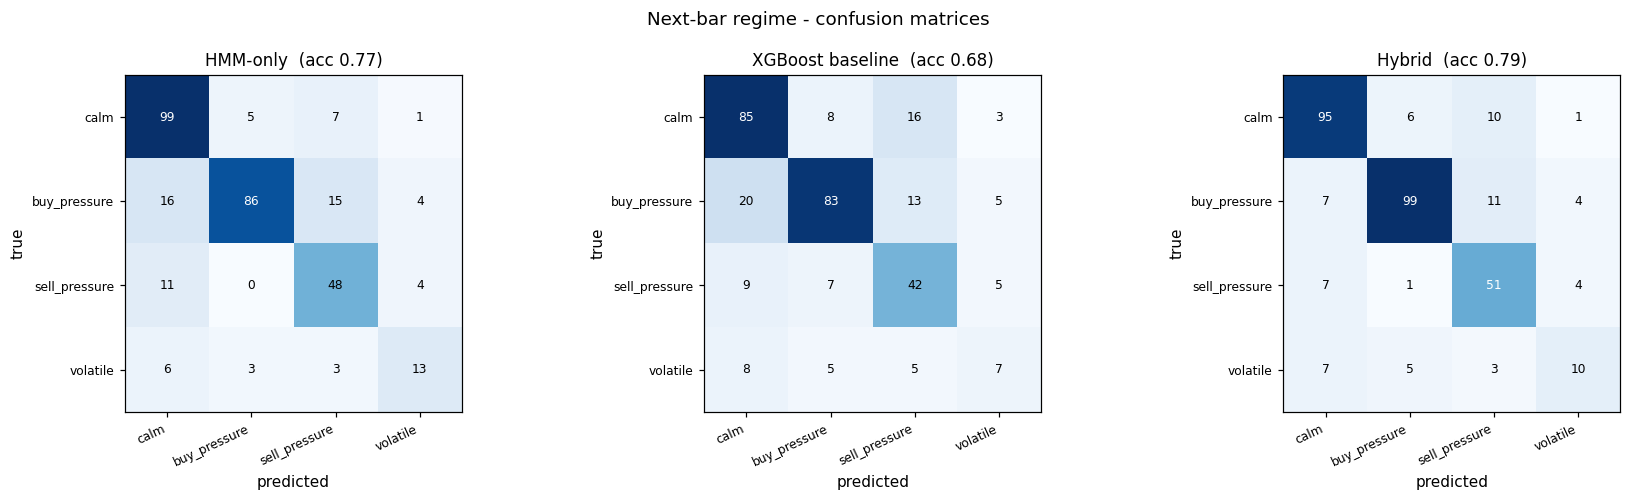

In [10]:
# Confusion matrices for all three models, side by side (rows = true, cols = predicted).
classes = sorted(REGIME_NAMES)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (title, pred) in zip(axes, [("HMM-only", hmm_pred),
                                     ("XGBoost baseline", baseline_pred),
                                     ("Hybrid", hybrid_pred)]):
    cm = confusion_matrix(target_test, pred, labels=classes)
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=25, ha="right", fontsize=8)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    acc = accuracy_score(target_test, pred)
    ax.set_title(f"{title}  (acc {acc:.2f})", fontsize=11)
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.suptitle("Next-bar regime - confusion matrices", fontsize=12)
plt.tight_layout(); plt.show()

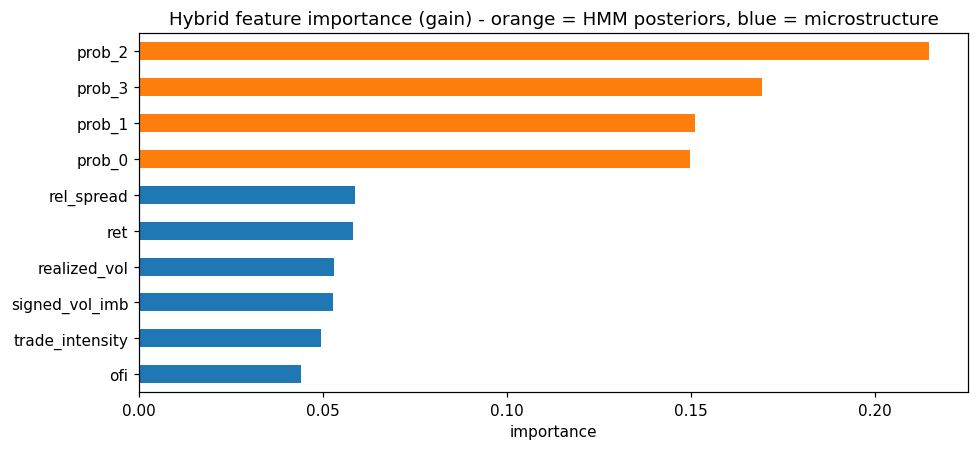

HMM posteriors account for 68% of total gain importance in the hybrid.


In [11]:
# Where does the hybrid get its signal? Highlight the HMM posteriors (orange) vs micro (blue).
importance = feature_importance(hybrid_clf, hybrid_cols).sort_values()
colors = ["#ff7f0e" if c.startswith("prob_") else "#1f77b4" for c in importance.index]

fig, ax = plt.subplots(figsize=(9, 4.2))
importance.plot.barh(ax=ax, color=colors)
ax.set_title("Hybrid feature importance (gain) - orange = HMM posteriors, blue = microstructure")
ax.set_xlabel("importance")
plt.tight_layout(); plt.show()

posterior_share = importance[[c for c in importance.index if c.startswith("prob_")]].sum()
print(f"HMM posteriors account for {posterior_share:.0%} of total gain importance in the hybrid.")

**Reading the forecasts as a timeline.** Each ribbon is the next-bar regime over the test period, colored by regime. The top row is the truth; below it, each model's forecast. Watch the **baseline flicker** (rapid color changes the truth does not have) versus the smoother HMM and hybrid ribbons — that flicker is the cost of having no persistence.

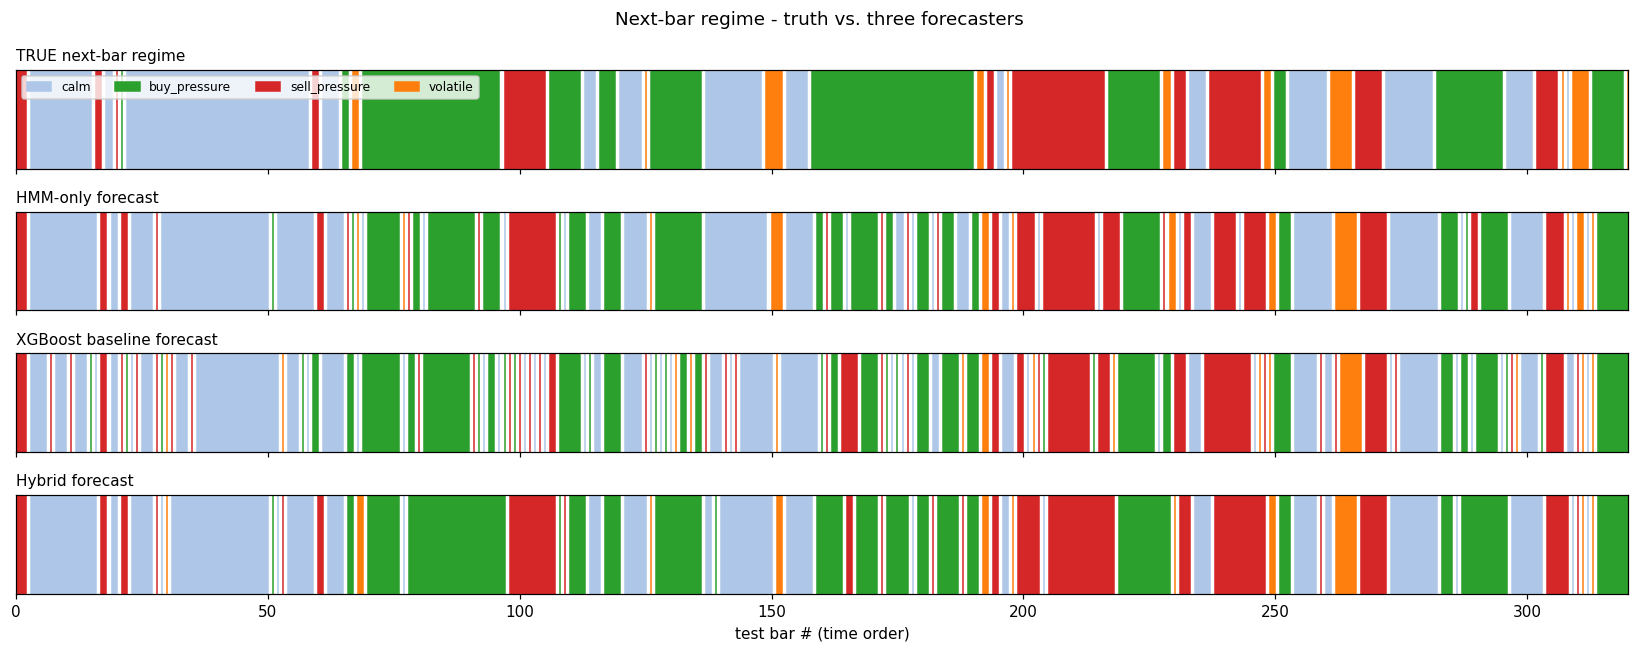

In [12]:
def ribbon(ax, labels, title):
    arr = np.asarray(labels); xs = np.arange(len(arr))
    for cls in sorted(REGIME_NAMES):
        ax.fill_between(xs, 0, 1, where=(arr == cls), step="mid",
                        color=REGIME_COLORS[cls], label=REGIME_NAMES[cls])
    ax.set_yticks([]); ax.set_ylim(0, 1); ax.set_xlim(0, len(arr) - 1)
    ax.set_title(title, fontsize=10, loc="left")

panels = [("TRUE next-bar regime", np.asarray(target_test)),
          ("HMM-only forecast", hmm_pred),
          ("XGBoost baseline forecast", baseline_pred),
          ("Hybrid forecast", hybrid_pred)]
fig, axff = plt.subplots(len(panels), 1, figsize=(15, 6), sharex=True)
for ax, (title, labels) in zip(axff, panels):
    ribbon(ax, labels, title)
axff[0].legend(loc="upper left", fontsize=8, ncol=4)
axff[-1].set_xlabel("test bar # (time order)")
fig.suptitle("Next-bar regime - truth vs. three forecasters")
plt.tight_layout(); plt.show()

## Robustness — walk-forward cross-validation

A single 70/30 split is one slice of luck. Walk-forward CV trains on the growing past and tests on each successive future block, giving several honest scores (mean ± spread). We compare baseline vs hybrid across folds.

> **Honest caveat.** For simplicity the HMM here is fit **once** on the first 70% (inside `train_and_backtest`), so its posteriors are slightly optimistic for the *earliest* CV folds (whose test bars fell inside that 70%). The clean fix — re-fitting the HMM inside each fold — is noted in "next steps"; it lowers the absolute numbers a little but the **baseline-vs-hybrid gap**, which is the point here, is stable across folds.

In [13]:
from src.xgb.walk_forward import cross_validate_forward

print("===== baseline (6 microstructure features) =====")
baseline_folds = cross_validate_forward(base_features, regime_target,
                                        n_folds=5, embargo=0, purge_horizon=1)
print("\n===== hybrid (6 microstructure + 4 HMM posteriors) =====")
hybrid_folds = cross_validate_forward(hybrid_features, regime_target,
                                      n_folds=5, embargo=0, purge_horizon=1)
print(f"\nmean macro-F1  baseline {baseline_folds.mean():.3f}  |  "
      f"hybrid {hybrid_folds.mean():.3f}  |  gap {hybrid_folds.mean() - baseline_folds.mean():+.3f}")

===== baseline (6 microstructure features) =====


fold 1: train= 177 test= 179  macro-F1=0.562


fold 2: train= 356 test= 179  macro-F1=0.667


fold 3: train= 535 test= 178  macro-F1=0.673


fold 4: train= 713 test= 179  macro-F1=0.600


...

fold 1: train= 177 test= 179  macro-F1=0.672


fold 2: train= 356 test= 179  macro-F1=0.746


fold 3: train= 535 test= 178  macro-F1=0.736


fold 4: train= 713 test= 179  macro-F1=0.674


fold 5: train= 892 test= 179  macro-F1=0.706

Walk-forward macro-F1: 0.707 +/- 0.031  (mean over 5folds )

mean macro-F1  baseline 0.621  |  hybrid 0.707  |  gap +0.086


## What it means

- **For *forecasting*, persistence beats microstructure-alone.** The microstructure-only XGBoost is the weakest of the three: with no memory it re-decides every bar and flickers. The HMM, whose transition matrix *is* memory, is a stronger next-bar forecaster despite being unsupervised. (This flips notebook 10's *detection* result, where the supervised model led — the task changed, so the winner did.)
- **The hybrid genuinely combines the two.** Handed the HMM posteriors, XGBoost reaches the HMM's persistence-driven macro-F1 **and** edges ahead on accuracy by exploiting microstructure the HMM ignores — and it crushes its own microstructure-only baseline by ~0.12 macro-F1. The posteriors are the top features by importance, confirming they supply what the raw features couldn't.
- **It's the same model, deployable on the real feed.** Nothing here used the future: the posteriors are online-filtered and the labels look one bar ahead. On the real proprietary feed the hybrid is buildable the moment the HMM runs.

But on this synthetic the hybrid only **ties** the HMM on macro-F1 — because the data has no feature-based early warning of regime change. The next section tests exactly that gap.

## Extension (H1) — When can the hybrid *beat* the HMM, not just match it?

The core result is honest but has a ceiling. On this synthetic, regime changes are **memoryless**: the next regime depends only on the current one, never on the features (the generator draws it as `rng.choice(4, p=TRANSITION[current])`). So there is **no microstructure early-warning** of a regime change for XGBoost to exploit — which is precisely *why* the hybrid only **tied** the HMM on macro-F1 above.

Real order flow plausibly *does* foreshadow regime shifts — activity and liquidity often move **before** volatility (recall `trade_intensity` was the top *predictive* feature in the gen-2 forecaster). So we run a controlled what-if: inject a **precursor** — a noisy `trade_intensity` spike on the bar **just before** each volatile onset — **without touching the labels**, then re-run all three models. If the hybrid can capture an early-warning the HMM structurally cannot, its edge should open up.

In [14]:
import io, contextlib

def forecast_three_models(features_in, truth_in, horizon=1):
    """Full pipeline -> results DataFrame for the 3 forecasters. Reuses exactly the
    src functions used above, so the methodology is identical to the headline result."""
    with contextlib.redirect_stdout(io.StringIO()):          # hush the BIC sweep
        frame, artifact, split_ix = train_and_backtest(features_in)
    n = artifact["meta"]["n_states"]
    pcols = [f"prob_{s}" for s in range(n)]

    target, valid = make_regime_forecast_target(features_in, truth_in, horizon=horizon)
    target = target[valid].astype(int)
    train_mask = (np.arange(len(features_in)) < split_ix)[valid.values]

    # train-only HMM-state -> regime map (same idea as the headline cells)
    reg_now = pd.Series([truth_in.get(ts.isoformat()) for ts in features_in.index],
                        index=features_in.index)
    state = frame["filt_state"]; in_train = np.arange(len(features_in)) < split_ix
    s2r = {}
    for s in range(n):
        m = (state.values == s) & in_train & reg_now.notna().values
        s2r[s] = int(pd.Series(reg_now.values[m]).mode().iloc[0]) if m.any() else 0

    base = frame.loc[valid, config.FEATURE_COLS]
    hyb = frame.loc[valid, config.FEATURE_COLS + pcols]
    y = target[~train_mask]

    probs = frame.loc[valid, pcols].values[~train_mask]
    hmm_p = np.array([s2r[s] for s in (probs @ artifact["model"].transmat_).argmax(1)])
    base_p = train_classifier(base[train_mask], target[train_mask]).predict(base[~train_mask])
    hyb_p = train_classifier(hyb[train_mask], target[train_mask]).predict(hyb[~train_mask])

    out = {}
    for nm, p in [("HMM-only", hmm_p), ("XGB baseline", base_p), ("Hybrid", hyb_p)]:
        out[nm] = {"accuracy": round(accuracy_score(y, p), 3),
                   "macro-F1": round(f1_score(y, p, average="macro"), 3)}
    return pd.DataFrame(out).T, n


def inject_early_warning(features_in, truth_in, boost=2.0, seed=0):
    """Simulate a microstructure precursor: on the bar JUST BEFORE each volatile
    onset, spike trade_intensity (noisy, multiplicative). Labels are UNTOUCHED, so
    this is a genuine leading indicator, not a relabel. Returns (modified copy, n_hit)."""
    rng = np.random.default_rng(seed)
    out = features_in.copy()
    reg = pd.Series([truth_in.get(ts.isoformat()) for ts in out.index], index=out.index)
    next_reg = reg.groupby([out["date"], out["session_id"]], sort=False).shift(-1)
    precursor = (reg != 3) & (next_reg == 3)             # 3 = volatile
    bump = 1 + boost * (0.5 + rng.random(int(precursor.sum())))
    out.loc[precursor, "trade_intensity"] = out.loc[precursor, "trade_intensity"].values * bump
    return out, int(precursor.sum())

In [15]:
results_plain, n_plain = forecast_three_models(features, truth)
features_ew, n_hit = inject_early_warning(features, truth, boost=2.0, seed=0)
results_ew, n_ew = forecast_three_models(features_ew, truth)

print(f"injected {n_hit} precursor bars (one before each volatile onset)")
print(f"HMM states by BIC: original={n_plain}, early-warning={n_ew}  (kept equal on purpose)\n")

compare = pd.concat({"original": results_plain["macro-F1"],
                     "early-warning": results_ew["macro-F1"]}, axis=1)
compare["change"] = (compare["early-warning"] - compare["original"]).round(3)
print("macro-F1 by model:")
print(compare.to_string())

gap_o = results_plain.loc["Hybrid", "macro-F1"] - results_plain.loc["HMM-only", "macro-F1"]
gap_e = results_ew.loc["Hybrid", "macro-F1"] - results_ew.loc["HMM-only", "macro-F1"]
print(f"\nhybrid - HMM (macro-F1):  original {gap_o:+.3f}  ->  early-warning {gap_e:+.3f}")

injected 30 precursor bars (one before each volatile onset)
HMM states by BIC: original=4, early-warning=4  (kept equal on purpose)

macro-F1 by model:
              original  early-warning  change
HMM-only         0.718          0.699  -0.019
XGB baseline     0.596          0.653   0.057
Hybrid           0.720          0.758   0.038

hybrid - HMM (macro-F1):  original +0.002  ->  early-warning +0.059


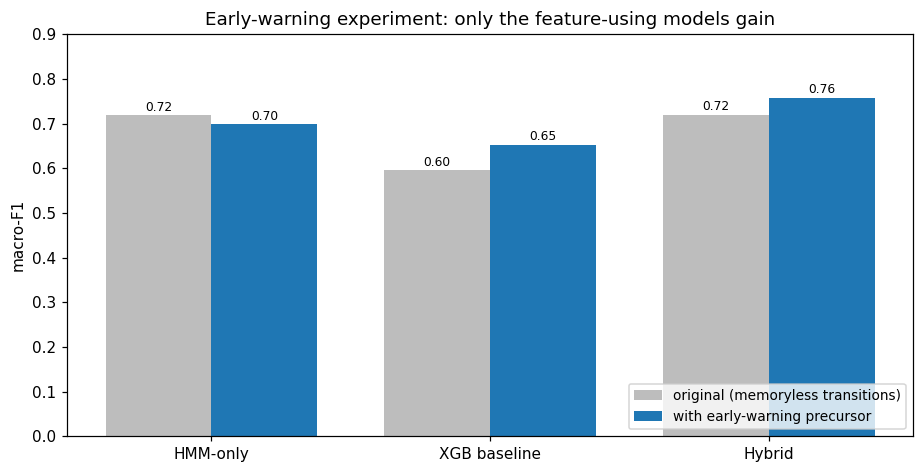

In [16]:
models = ["HMM-only", "XGB baseline", "Hybrid"]
x = np.arange(len(models)); w = 0.38

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.bar(x - w/2, results_plain.loc[models, "macro-F1"], w,
       label="original (memoryless transitions)", color="#bdbdbd")
ax.bar(x + w/2, results_ew.loc[models, "macro-F1"], w,
       label="with early-warning precursor", color="#1f77b4")
for i, m in enumerate(models):
    ax.text(i - w/2, results_plain.loc[m, "macro-F1"] + 0.01,
            f"{results_plain.loc[m, 'macro-F1']:.2f}", ha="center", fontsize=8)
    ax.text(i + w/2, results_ew.loc[m, "macro-F1"] + 0.01,
            f"{results_ew.loc[m, 'macro-F1']:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel("macro-F1"); ax.set_ylim(0, 0.9)
ax.set_title("Early-warning experiment: only the feature-using models gain")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

**What happened.** With the precursor present:

- the **HMM-only** forecast barely moves (it even dips a touch) — its transition matrix is memoryless *given the current state*, so it has no mechanism to turn *"intensity is spiking now"* into *"volatile next"*;
- the **XGBoost baseline** improves (macro-F1 ~0.60 → ~0.65) — proof the early-warning is real and lives in the features;
- the **hybrid** improves most (~0.72 → ~0.76) and **pulls clearly ahead of the HMM** (gap +0.00 → ~+0.06 macro-F1), combining the new microstructure signal with the HMM's persistence.

We kept the precursor **moderate** on purpose: strong enough to be learnable, weak enough that BIC still selects **4** HMM states — otherwise the HMM bolts on an extra state to chase the precursor and the comparison is no longer apples-to-apples.

**Why this matters for the real feed.** This is the signature to hunt for in the proprietary order flow. If regime shifts are foreshadowed by microstructure — as they often are in real markets — the hybrid converts that foreshadowing into forecasting edge the HMM alone cannot reach. On the memoryless synthetic the hybrid *matches* the HMM; give it a real early-warning and it *beats* it.

## Honest caveats & next steps

**Caveats**
- **Synthetic labels.** The next-bar regime label comes from the generator's ground truth. On the real feed there is no truth column — see the real-data target below.
- **One instrument, one seed.** Numbers will move on other symbols/seeds; the *ordering* (hybrid ≥ HMM > microstructure-only for forecasting) is the durable finding, not the exact decimals.
- **The early-warning precursor (H1) is injected, not discovered.** It demonstrates *what the hybrid can do if* such a signal exists; whether the real feed actually contains one is an empirical question for when we have data.
- **Walk-forward HMM leak.** The HMM is fit once on the first 70%; a per-fold re-fit is the rigorous version.

**Next steps**
1. **Real-data target — "HMM-as-teacher."** With no ground-truth regimes, forecast the **HMM's own next filtered state** instead of the true regime (`make_regime_forecast_target` accepts any per-bar label source). The hybrid then learns a *microstructure-aware transition model*: "given the current posterior **and** the order flow, what will the HMM say next?" — a learned refinement of the HMM's plain transition matrix.
2. **Re-fit the HMM per walk-forward fold** to remove the small leak above.
3. **Forecast further out** (`horizon = 2, 3, …`). With the early-warning signal of H1 present, the hybrid's edge should *widen* with horizon (persistence decays, so feature-based foresight matters more); on the memoryless base data it would instead shrink toward the majority class. Worth measuring both.
4. **Promote to a module** once the shape is settled: a small `src/xgb/hybrid.py` that assembles `[microstructure | posteriors]` and reuses `train_classifier`, so the notebook becomes a thin demo over committed code (mirroring how `run_xgb_forward.py` backs notebook-10's forecaster).